# MobileNet Transfer Learning for Deepfake Audio Detection

This notebook trains a MobileNet-based model for classifying audio spectrograms as real or fake.

## Model Architecture:
- **Base**: MobileNet pretrained on ImageNet (frozen layers)
- **Head**: GlobalAveragePooling2D → Dense(2, sigmoid)
- **Output**: Binary classification (real vs fake)

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# TensorFlow configuration
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.18.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration

In [2]:
# Paths
BASE_DIR = Path('../')
SPECTROGRAM_DIR = BASE_DIR / 'data' / 'spectrograms'
MODEL_DIR = BASE_DIR / 'models' / 'audio' / 'mobilenet'

# Training parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 20

# Class names
CLASS_NAMES = ['fake', 'real']

print(f"Spectrogram directory: {SPECTROGRAM_DIR}")
print(f"Model output directory: {MODEL_DIR}")

Spectrogram directory: ../data/spectrograms
Model output directory: ../models/audio/mobilenet


## Load Dataset

In [3]:
# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPECTROGRAM_DIR / 'training'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPECTROGRAM_DIR / 'validation'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPECTROGRAM_DIR / 'testing'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=42
)

print(f"\nClass names: {train_ds.class_names}")

Found 13956 files belonging to 2 classes.
Found 2826 files belonging to 2 classes.
Found 1088 files belonging to 2 classes.

Class names: ['fake', 'real']


2026-01-10 19:11:52.124185: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-01-10 19:11:52.124207: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-10 19:11:52.124209: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1768068712.124416 1125409 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1768068712.124574 1125409 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Build MobileNet Model

In [5]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Rescaling
from tensorflow.keras.models import Model

# Load MobileNet base model (pretrained on ImageNet)
base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

print(f"Base model layers: {len(base_model.layers)}")
print(f"Trainable layers: {sum(1 for l in base_model.layers if l.trainable)}")

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model layers: 86
Trainable layers: 0


In [6]:
# Build model with custom classification head
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Normalize input
x = Rescaling(1./255)(inputs)

# Pass through MobileNet base
x = base_model(x, training=False)

# Classification head
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation='sigmoid')(x)

# Create model
model = Model(inputs, outputs, name='mobilenet_deepfake_detector')

model.summary()

Model: "mobilenet_deepfake_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,229,889 (12.32 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [7]:
# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


## Train Model

In [8]:
# Define callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7
    )
]

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


2026-01-10 19:11:54.491180: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


437/437 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.8875 - loss: 0.2877 - val_accuracy: 0.9430 - val_loss: 0.1775 - learning_rate: 0.0010
Epoch 2/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 30s 69ms/step - accuracy: 0.9525 - loss: 0.1465 - val_accuracy: 0.9558 - val_loss: 0.1352 - learning_rate: 0.0010
Epoch 3/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 30s 69ms/step - accuracy: 0.9625 - loss: 0.1157 - val_accuracy: 0.9614 - val_loss: 0.1163 - learning_rate: 0.0010
Epoch 4/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.9680 - loss: 0.0992 - val_accuracy: 0.9650 - val_loss: 0.1048 - learning_rate: 0.0010
Epoch 5/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.9714 - loss: 0.0881 - val_accuracy: 0.9682 - val_loss: 0.0967 - learning_rate: 0.0010
Epoch 6/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.9736 - loss: 0.0800 - val_accuracy: 0.9699 - val_loss: 0.0907 - learning_rate: 0.0010
Epoch 7/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 30s 69ms/step - accuracy: 0.9764 - loss: 0.0736

## Training Results

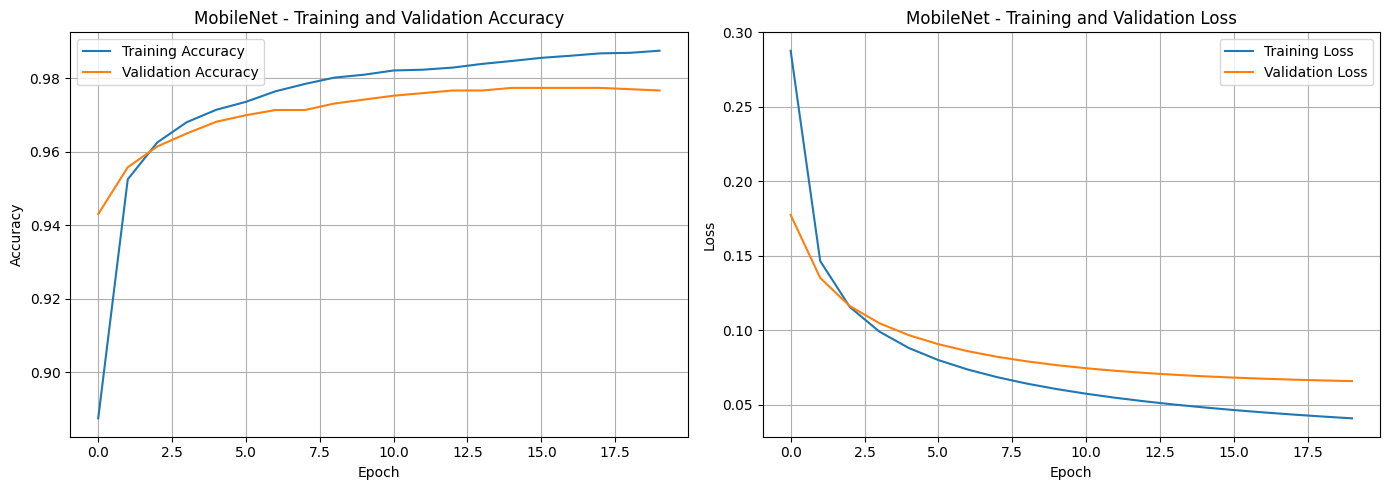

In [9]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('MobileNet - Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('MobileNet - Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Evaluate on Test Set

In [10]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.7822 - loss: 0.4805

Test Loss: 0.4805
Test Accuracy: 0.7822


Classification Report:
              precision    recall  f1-score   support

        fake       0.83      0.71      0.76       544
        real       0.74      0.86      0.80       544

    accuracy                           0.78      1088
   macro avg       0.79      0.78      0.78      1088
weighted avg       0.79      0.78      0.78      1088



2026-01-10 19:22:00.763806: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


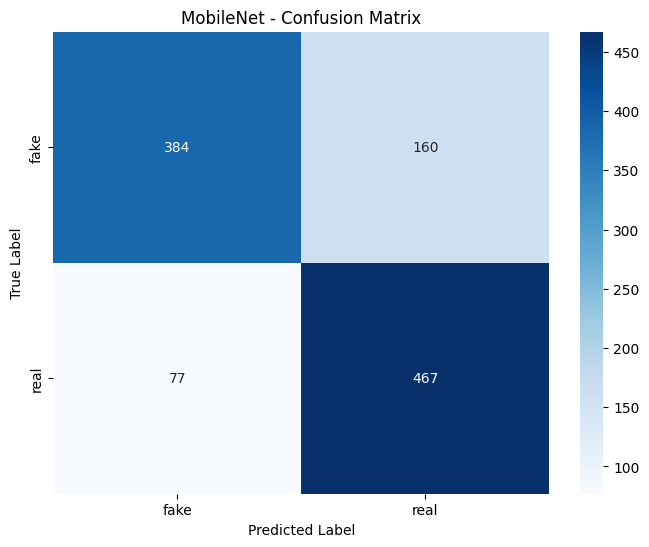

In [11]:
# Generate predictions for confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('MobileNet - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Save Model

In [13]:
# Create model directory if it doesn't exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save as .keras format
MODEL_PATH = MODEL_DIR / 'mobilenet_model.keras'
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# Load the model
loaded_model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")
print("Input shape:", loaded_model.input_shape)
print("Output shape:", loaded_model.output_shape)

Model saved to: ../models/audio/mobilenet/mobilenet_model.keras
Model loaded successfully!
Input shape: (None, 224, 224, 3)
Output shape: (None, 1)


## Summary

The MobileNet model has been trained and saved to `models/audio/mobilenet/`.

### Model Details:
- **Base**: MobileNet pretrained on ImageNet (frozen)
- **Custom head**: GlobalAveragePooling2D → Dense(1, sigmoid)
- **Input**: 224x224x3 RGB spectrograms
- **Output**: Binary probability (fake/real)

The model can be loaded for inference using:
```python
model = tf.keras.models.load_model('models/audio/mobilenet')
```